## Summative Lab: Forest Fires Prevention

### Step 1: Load the Dataset

* Install and import the ucimlrepo library.
* Load the Forest Fires dataset:
  * Predictors: Features from `forest_fires.data.features`.
  * Target: `forest_fires.data.targets`.

In [9]:
# Run pip install if necessary to access the UCI ML Repository
#! pip install ucimlrepo


In [10]:
# Data
from ucimlrepo import fetch_ucirepo

forest_fires = fetch_ucirepo(id=162)
X = forest_fires.data.features
y = forest_fires.data.targets

# Display dataset structure
print(X.info())
print(X.describe())
print(y.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
dtypes: float64(7), int64(3), object(2)
memory usage: 48.6+ KB
None
                X           Y        FFMC         DMC          DC         ISI  \
count  517.000000  517.000000  517.000000  517.000000  517.000000  517.000000   
mean     4.669246    4.299807   90.644681  110.872340  547.940039    9.021663   
std      2.313778    1.229900    5.520111   64.046482  248.066192 

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import OLSInfluence, variance_inflation_factor

#merging the data
df = pd.concat([X, y], axis=1)
df.head()


,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


### Step 2: Exploratory Data Analysis (EDA)

* Examine the dataset structure and summary statistics.
* Analyze correlations between predictors and the target variable.
* Plot scatterplots for key predictors vs. the target.
* Generate a residual plot to check for randomness in residuals.

In [12]:
# Structure / summary statistics
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
print(df['area'].describe())
print("Share of records with area == 0:", (df['area'] == 0).mean())


(517, 13)
X          int64
Y          int64
month     object
day       object
FFMC     float64
DMC      float64
DC       float64
ISI      float64
temp     float64
RH         int64
wind     float64
rain     float64
area     float64
dtype: object
X        0
Y        0
month    0
day      0
FFMC     0
DMC      0
DC       0
ISI      0
temp     0
RH       0
wind     0
rain     0
area     0
dtype: int64
count     517.000000
mean       12.847292
std        63.655818
min         0.000000
25%         0.000000
50%         0.520000
75%         6.570000
max      1090.840000
Name: area, dtype: float64
Share of records with area == 0: 0.47775628626692457


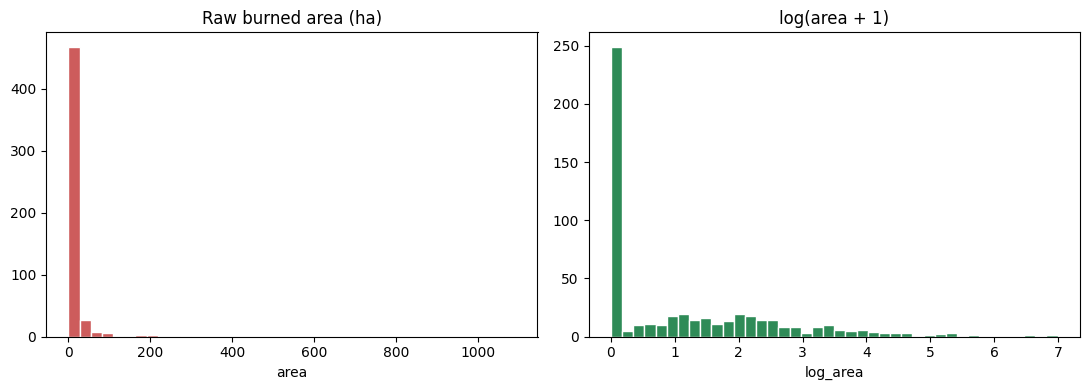

In [13]:
df['log_area'] = np.log1p(df['area'])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df['area'], bins=40, color='indianred', edgecolor='white')
axes[0].set_title('Raw burned area (ha)'); axes[0].set_xlabel('area')
axes[1].hist(df['log_area'], bins=40, color='seagreen', edgecolor='white')
axes[1].set_title('log(area + 1)'); axes[1].set_xlabel('log_area')
plt.tight_layout()
plt.show()


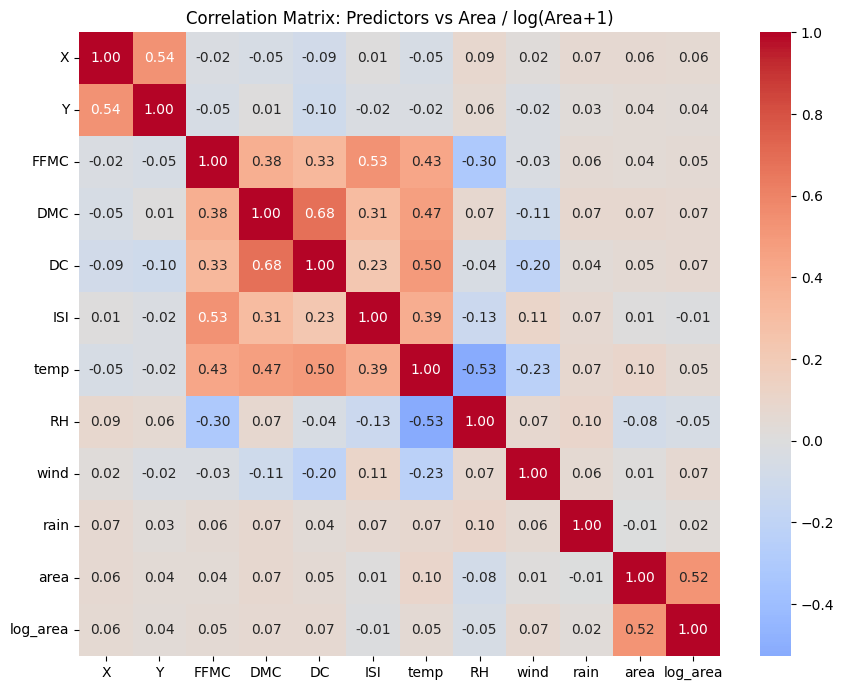

,log_area
log_area,1.000000
area,0.524134
DMC,0.067153
wind,0.066973
DC,0.066360
X,0.061995
temp,0.053487
FFMC,0.046799
Y,0.038838
rain,0.023311


In [14]:
# Correlation between predictors and the (log-transformed) target
num_cols = ['X', 'Y', 'FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain']

plt.figure(figsize=(9, 7))
corr = df[num_cols + ['area', 'log_area']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix: Predictors vs Area / log(Area+1)')
plt.tight_layout()
plt.show()

corr['log_area'].sort_values(ascending=False)


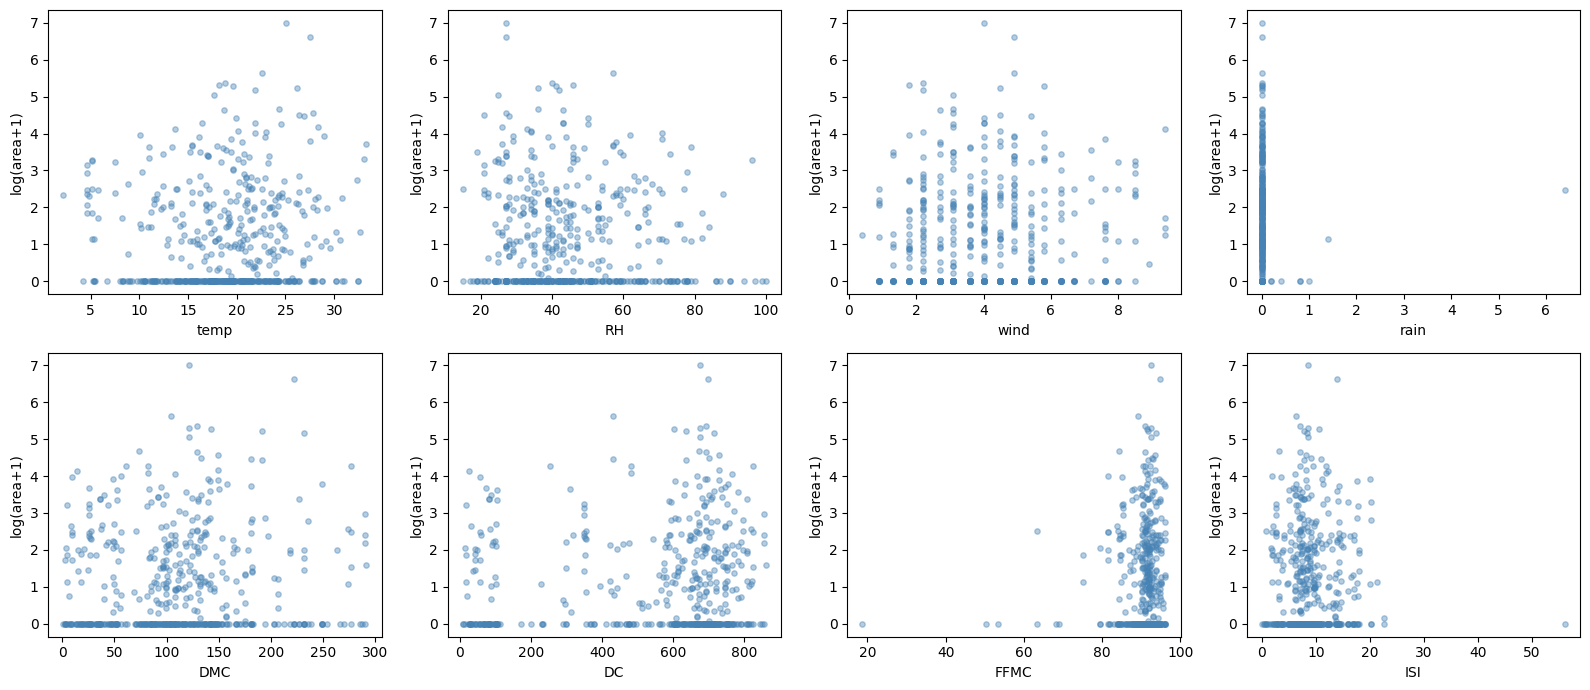

In [15]:
# Scatterplots: key predictors vs. log(area + 1)
key_preds = ['temp', 'RH', 'wind', 'rain', 'DMC', 'DC', 'FFMC', 'ISI']
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, key_preds):
    ax.scatter(df[col], df['log_area'], alpha=0.4, s=15, color='steelblue')
    ax.set_xlabel(col); ax.set_ylabel('log(area+1)')
plt.tight_layout()
plt.show()


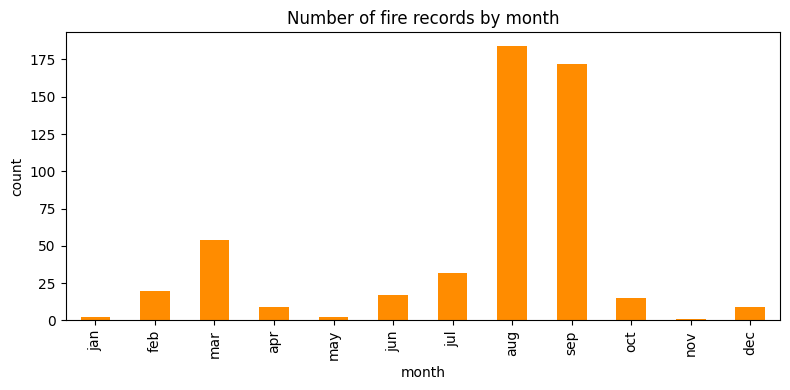

In [16]:
# Fires by month (seasonality)
month_order = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
plt.figure(figsize=(8, 4))
df['month'].value_counts().reindex(month_order).fillna(0).plot(kind='bar', color='darkorange')
plt.title('Number of fire records by month'); plt.ylabel('count')
plt.tight_layout()
plt.show()


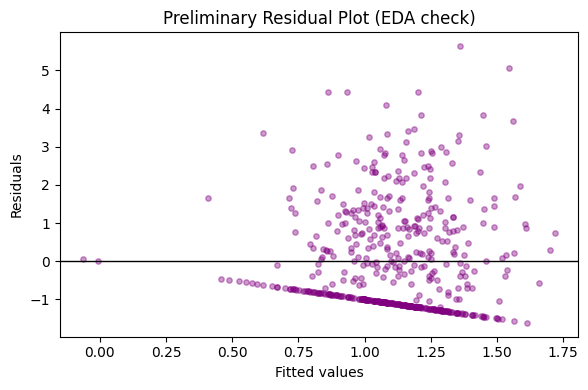

In [17]:
# baseline model
X_prelim = sm.add_constant(df[num_cols])
prelim_model = sm.OLS(df['log_area'], X_prelim).fit()

plt.figure(figsize=(6, 4))
plt.scatter(prelim_model.fittedvalues, prelim_model.resid, alpha=0.4, s=15, color='purple')
plt.axhline(0, color='black', lw=1)
plt.xlabel('Fitted values'); plt.ylabel('Residuals')
plt.title('Preliminary Residual Plot (EDA check)')
plt.tight_layout()
plt.show()


### Step 3: Fit the Regression Models

* Fit a baseline multiple linear regression model with key predictors.
* Include nonlinear terms (e.g., quadratic transformations for significant predictors).
* Add interaction terms (e.g., between predictors with strong correlations).
* Incorporate indicator variables if categorical variables are present.
* Apply transformations (e.g., logarithmic transformations for skewed predictors).

In [18]:
# Model A: baseline multiple linear regression on the raw weather / FWI predictors
featsA = ['temp', 'RH', 'wind', 'rain', 'DMC', 'DC', 'FFMC', 'ISI']

Xa = sm.add_constant(df[featsA])
model_a = sm.OLS(df['log_area'], Xa).fit()
print(model_a.summary())


                            OLS Regression Results                            
Dep. Variable:               log_area   R-squared:                       0.020
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     1.288
Date:                Fri, 25 Sep 2026   Prob (F-statistic):              0.247
Time:                        21:13:17   Log-Likelihood:                -901.28
No. Observations:                 517   AIC:                             1821.
Df Residuals:                     508   BIC:                             1859.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2224      1.360      0.163      0.8

In [19]:
# Model B: engineered model
# - quadratic term on temp (fire risk can rise non-linearly with heat)
# - interaction term temp x wind (hot + windy conditions compound fire spread)
# - log-transform of 'rain' (extremely skewed: mostly 0 with a few large values)
# - indicator variables for peak fire season (Jun-Aug) and weekend (staffing proxy)
df['is_summer'] = df['month'].isin(['jun', 'jul', 'aug']).astype(int)
df['is_weekend'] = df['day'].isin(['sat', 'sun']).astype(int)
df['log_rain'] = np.log1p(df['rain'])
df['temp_sq'] = df['temp'] ** 2
df['temp_wind'] = df['temp'] * df['wind']

featsB = ['temp', 'temp_sq', 'RH', 'wind', 'log_rain', 'DMC', 'DC', 'FFMC', 'ISI',
          'temp_wind', 'is_summer', 'is_weekend']

Xb = sm.add_constant(df[featsB])
model_b = sm.OLS(df['log_area'], Xb).fit()
print(model_b.summary())


                            OLS Regression Results                            
Dep. Variable:               log_area   R-squared:                       0.051
Model:                            OLS   Adj. R-squared:                  0.028
Method:                 Least Squares   F-statistic:                     2.250
Date:                Fri, 25 Sep 2026   Prob (F-statistic):            0.00894
Time:                        21:13:18   Log-Likelihood:                -892.98
No. Observations:                 517   AIC:                             1812.
Df Residuals:                     504   BIC:                             1867.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1491      1.467     -0.102      0.9

### Step 4: Evaluate Model Diagnostics

* Compare models using metrics like R², adjusted R², AIC, and BIC.
* Plot residuals and create Q-Q plots to assess normality.
* Identify influential observations using Cook's Distance.

In [20]:
# R2 / adjusted R2 / AIC / BIC comparison
comparison = pd.DataFrame({
    'Model': ['A: baseline', 'B: engineered'],
    'R2': [model_a.rsquared, model_b.rsquared],
    'Adj R2': [model_a.rsquared_adj, model_b.rsquared_adj],
    'AIC': [model_a.aic, model_b.aic],
    'BIC': [model_a.bic, model_b.bic],
})
comparison


,Model,R2,Adj R2,AIC,BIC
0,A: baseline,0.019881,0.004446,1820.555830,1858.788216
1,B: engineered,0.050843,0.028244,1811.960463,1867.185021


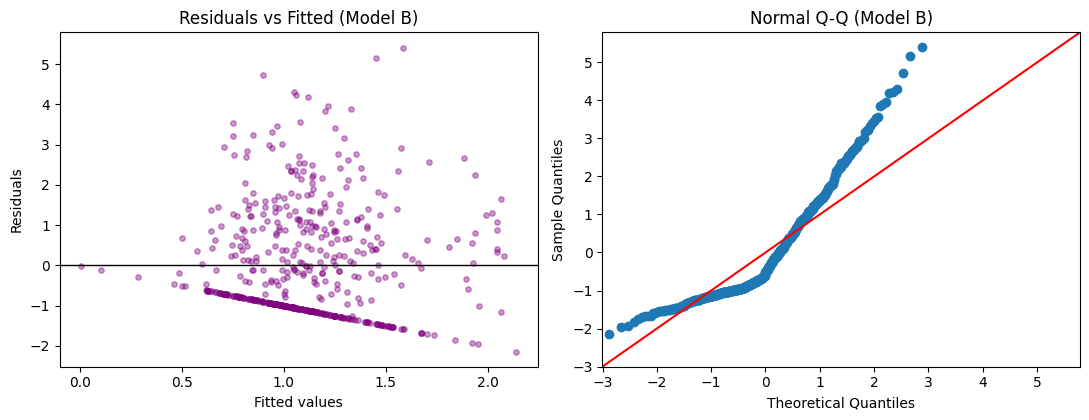

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
axes[0].scatter(model_b.fittedvalues, model_b.resid, alpha=0.4, s=15, color='purple')
axes[0].axhline(0, color='black', lw=1)
axes[0].set_xlabel('Fitted values'); axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted (Model B)')

sm.qqplot(model_b.resid, line='45', ax=axes[1])
axes[1].set_title('Normal Q-Q (Model B)')
plt.tight_layout()
plt.show()


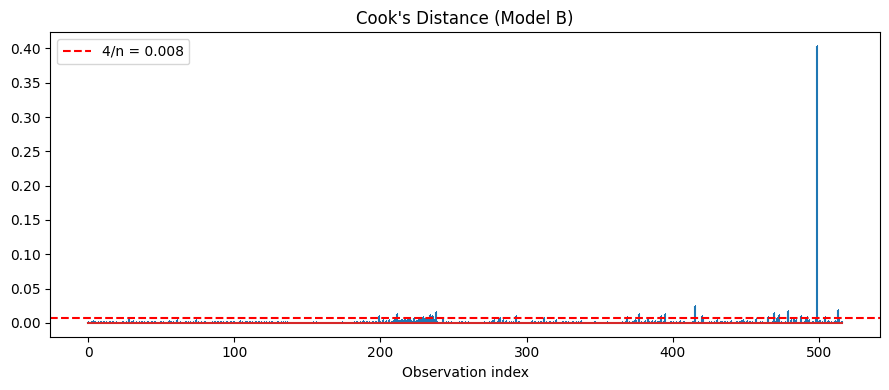

Influential points (Cook's D > 4/n): 26 of 517 observations (5.0%)


In [22]:
# Cook's Distance
influence_b = OLSInfluence(model_b)
cooks_d = influence_b.cooks_distance[0]

plt.figure(figsize=(9, 4))
plt.stem(np.arange(len(cooks_d)), cooks_d, markerfmt=",")
thresh = 4 / model_b.nobs
plt.axhline(thresh, color='red', ls='--', label=f'4/n = {thresh:.3f}')
plt.title("Cook's Distance (Model B)")
plt.xlabel('Observation index'); plt.legend()
plt.tight_layout()
plt.show()

n_influential = np.sum(cooks_d > thresh)
print(f"Influential points (Cook's D > 4/n): {n_influential} of {int(model_b.nobs)} observations "
      f"({n_influential / model_b.nobs:.1%})")


### Step 5: Apply Regularization

* Use Ridge (L2) and Lasso (L1) regression from sklearn to handle multicollinearity.
* Extract coefficients and calculate Mean Squared Error (MSE).
* Compare the performance of Ridge and Lasso models.

In [23]:
from sklearn.linear_model import RidgeCV, LassoCV, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

feats = featsB   # the richer, more collinear feature set is where regularization is most useful
Xr = df[feats].values
yr = df['log_area'].values

Xtr, Xte, ytr, yte = train_test_split(Xr, yr, test_size=0.2, random_state=42)
scaler = StandardScaler().fit(Xtr)
Xtr_s, Xte_s = scaler.transform(Xtr), scaler.transform(Xte)

lr = LinearRegression().fit(Xtr_s, ytr)
mse_lr = mean_squared_error(yte, lr.predict(Xte_s))

alphas = np.logspace(-3, 3, 50)
ridge = RidgeCV(alphas=alphas, store_cv_results=True).fit(Xtr_s, ytr)
mse_ridge = mean_squared_error(yte, ridge.predict(Xte_s))

lasso = LassoCV(alphas=alphas, cv=5, random_state=42, max_iter=20000).fit(Xtr_s, ytr)
mse_lasso = mean_squared_error(yte, lasso.predict(Xte_s))

print(f"Linear MSE (test): {mse_lr:.4f}")
print(f"Ridge  best alpha={ridge.alpha_:.4f}  MSE(test)={mse_ridge:.4f}")
print(f"Lasso  best alpha={lasso.alpha_:.4f}  MSE(test)={mse_lasso:.4f}")
print(f"Lasso zeroed-out {np.sum(lasso.coef_ == 0)} of {len(feats)} coefficients")


Linear MSE (test): 2.1426
Ridge  best alpha=1000.0000  MSE(test)=2.1782
Lasso  best alpha=1000.0000  MSE(test)=2.1992
Lasso zeroed-out 12 of 12 coefficients


       feature    Linear     Ridge  Lasso
0         temp -0.273626  0.005767    0.0
1      temp_sq  0.629128  0.019976    0.0
2           RH  0.034506 -0.005173   -0.0
3         wind  0.398810  0.017289    0.0
4     log_rain  0.004294  0.002626    0.0
5          DMC  0.196412  0.034343    0.0
6           DC -0.020828  0.017545    0.0
7         FFMC  0.094999  0.019359    0.0
8          ISI -0.082919 -0.010594   -0.0
9    temp_wind -0.389179 -0.003261    0.0
10   is_summer -0.165958 -0.026658   -0.0
11  is_weekend  0.004514 -0.001627   -0.0


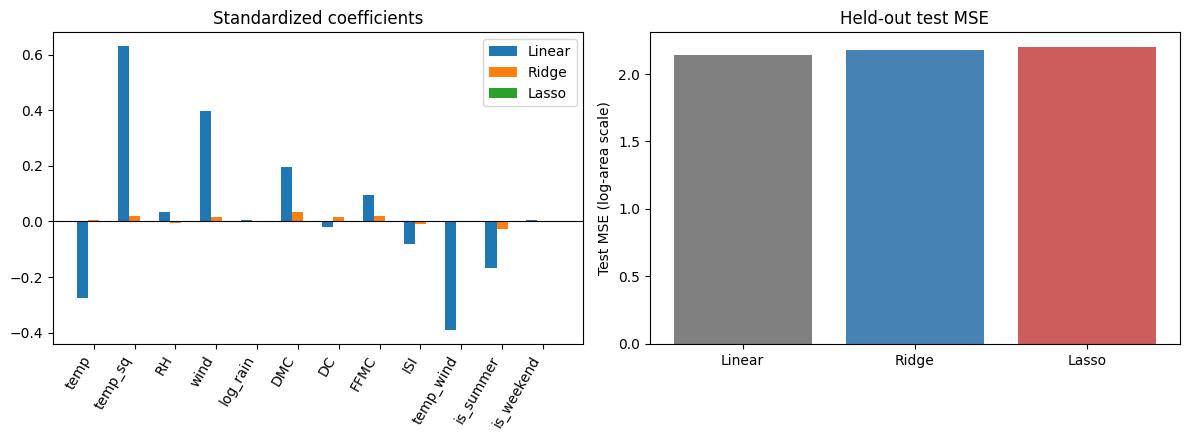

In [24]:
coef_table = pd.DataFrame({
    'feature': feats,
    'Linear': lr.coef_,
    'Ridge': ridge.coef_,
    'Lasso': lasso.coef_,
})
print(coef_table)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
x_pos = np.arange(len(feats)); width = 0.27
ax[0].bar(x_pos - width, lr.coef_, width, label='Linear')
ax[0].bar(x_pos, ridge.coef_, width, label='Ridge')
ax[0].bar(x_pos + width, lasso.coef_, width, label='Lasso')
ax[0].set_xticks(x_pos); ax[0].set_xticklabels(feats, rotation=60, ha='right')
ax[0].axhline(0, color='black', lw=0.8); ax[0].legend()
ax[0].set_title('Standardized coefficients')

ax[1].bar(['Linear', 'Ridge', 'Lasso'], [mse_lr, mse_ridge, mse_lasso],
          color=['gray', 'steelblue', 'indianred'])
ax[1].set_ylabel('Test MSE (log-area scale)'); ax[1].set_title('Held-out test MSE')
plt.tight_layout()
plt.show()


### Step 6: Prepare the Data for Binary Classification

* Create a binary target variable based on a threshold in y (e.g., median or other percentile).
* Select relevant predictors and scale them using StandardScaler.

In [25]:
# Binary target: does this fire burn MORE than the median burned area?
median_area = df['area'].median()
df['high_risk'] = (df['area'] > median_area).astype(int)

print("Median area threshold:", median_area)
print(df['high_risk'].value_counts())


Median area threshold: 0.52
high_risk
0    259
1    258
Name: count, dtype: int64


In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score)

Xc = df[featsB].values
yc = df['high_risk'].values

Xtr_c, Xte_c, ytr_c, yte_c = train_test_split(Xc, yc, test_size=0.25, random_state=42, stratify=yc)
scaler_c = StandardScaler().fit(Xtr_c)
Xtr_cs, Xte_cs = scaler_c.transform(Xtr_c), scaler_c.transform(Xte_c)

print("Train class balance:", ytr_c.mean().round(3))
print("Test class balance:", yte_c.mean().round(3))


Train class balance: 0.499
Test class balance: 0.5


### Step 7: Train and Evaluate a Logistic Regression Model

Train a logistic regression model using the scaled predictors.

* Display coefficients and the intercept.
* Predict probabilities and binary outcomes.
* Evaluate performance using accuracy, confusion matrix, precision, recall, and F1-score.

In [27]:
logit = LogisticRegression(max_iter=2000).fit(Xtr_cs, ytr_c)

coef_df = pd.DataFrame({'feature': featsB, 'coefficient': logit.coef_[0]})
print(coef_df)
print("intercept:", logit.intercept_[0])


       feature  coefficient
0         temp    -0.525301
1      temp_sq     0.983733
2           RH    -0.034605
3         wind     0.761740
4     log_rain     0.018263
5          DMC     0.056497
6           DC     0.141599
7         FFMC     0.239050
8          ISI    -0.149711
9    temp_wind    -0.737550
10   is_summer    -0.015506
11  is_weekend     0.004548
intercept: -0.00340351805502598


Accuracy=0.546  Precision=0.547  Recall=0.538  F1=0.543  AUC=0.551


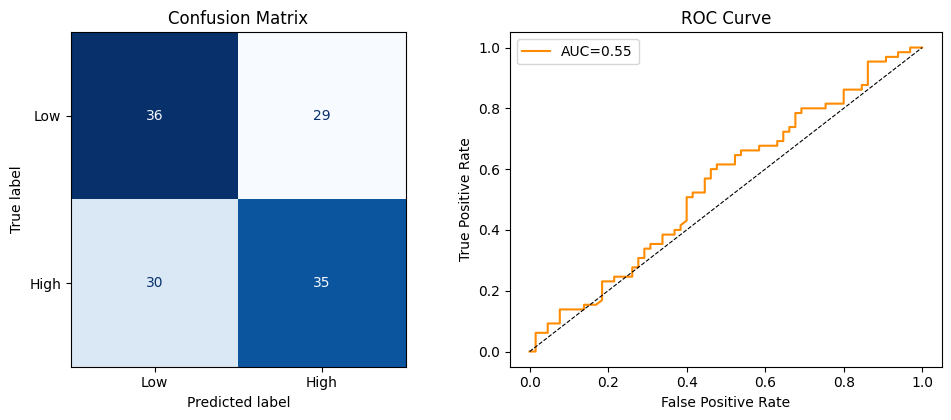

In [28]:
pred = logit.predict(Xte_cs)
proba = logit.predict_proba(Xte_cs)[:, 1]

acc = accuracy_score(yte_c, pred)
prec = precision_score(yte_c, pred)
rec = recall_score(yte_c, pred)
f1 = f1_score(yte_c, pred)
auc = roc_auc_score(yte_c, proba)
print(f"Accuracy={acc:.3f}  Precision={prec:.3f}  Recall={rec:.3f}  F1={f1:.3f}  AUC={auc:.3f}")

cm = confusion_matrix(yte_c, pred)
fig, axes = plt.subplots(1, 2, figsize=(10, 4.3))

ConfusionMatrixDisplay(cm, display_labels=['Low', 'High']).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix')

fpr, tpr, _ = roc_curve(yte_c, proba)
axes[1].plot(fpr, tpr, color='darkorange', label=f'AUC={auc:.2f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=0.8)
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve'); axes[1].legend()
plt.tight_layout()
plt.show()


### Step 8: Check Assumptions

* Use Variance Inflation Factor (VIF) to assess multicollinearity among predictors.

In [29]:
X_vif = df[featsB]
vif_data = pd.DataFrame()
vif_data['feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
vif_data.sort_values('VIF', ascending=False)


,feature,VIF
0,temp,46.230869
1,temp_sq,25.325154
9,temp_wind,13.393772
3,wind,10.556001
5,DMC,2.678985
6,DC,2.548017
2,RH,2.277486
10,is_summer,1.814967
7,FFMC,1.787505
8,ISI,1.682458


### Step 9: Summarize Findings

* Compare regression models and classification results.
* Highlight trade-offs between model simplicity, performance, and interpretability.
* Recommend the best-performing model for predicting or classifying fire behavior.

## Final Findings & Recommendations

Regression models. Model B (the engineered one with temp_sq, temp_wind, log_rain, and the season/weekend indicators) fits a bit better than Model A — R² goes from 0.020 to 0.051 and AIC drops slightly. BIC actually prefers Model A though, since it penalizes extra parameters more, and Model B added four terms for not much gain. Looking at Model B's coefficients, only temp_sq is actually significant (p = 0.007), and is_summer is borderline (p = 0.052). None of the raw weather variables (temp, RH, wind, rain, DMC, DC, FFMC, ISI) hit significance in either model. So the engineering helped a little, but basically all of it came from the temperature curvature, not the interaction or indicator terms.

Regularization. Ridge (test MSE 2.178) and Lasso (2.199) both did slightly worse than plain OLS (2.143), and both got pushed to their max shrinkage by cross-validation — Lasso actually zeroed out every single coefficient. That's a pretty strong signal that there isn't much real linear relationship between same-day weather/FWI values and burned area. OLS's bigger coefficients (like temp_wind at -0.39) are probably just picking up noise from the multicollinearity rather than a real effect.

Classification. Logistic regression predicting high vs. low burned area (split at the median) got accuracy 0.546, F1 0.543, AUC 0.551 — barely better than a coin flip. Biggest coefficients were temp_sq, temp_wind, and wind, which lines up with intuition (heat + wind = worse fires), but the model just isn't discriminating well. Turning it into a classification problem didn't fix the underlying issue — same weak features, same weak signal.

Trade-offs. Model A is simpler and doesn't have multicollinearity problems (VIF under 3 everywhere). Model B fits marginally better by AIC but its temperature terms have VIF as high as 46, so you really can't trust the individual coefficients there — only the combined effect. OLS gets the lowest test MSE but for the same multicollinearity reason, its coefficients aren't very trustworthy either. Ridge is a reasonable middle ground: keeps all predictors, shrinks them to something more stable, costs almost nothing in MSE. Lasso is the most honest about how little signal there is, but it gives up on interpreting individual weather effects entirely.

Recommendation. None of these models are good enough to deploy as a standalone predictor — R² tops out around 0.05 and classification accuracy is only 55%. If I had to pick:

For explaining results to someone (a report/briefing), i would go with Model A — simpler, no multicollinearity issues, and BIC backs it up.
For actual prediction, Ridge on the Model B features is the better call over OLS or Lasso — it handles the collinearity without throwing away all the signal like Lasso did.
The classification model (AUC 0.55) isn't reliable enough to drive resource decisions on its own — the seasonal pattern from the EDA (fires cluster hard in Aug–Sept) is honestly a more dependable signal than anything the models produced.


